# 08 — Elo Ratings Analysis

Explore the custom MLS Elo rating system:
- Current power rankings
- Elo trajectory over time
- Season-over-season progression
- Elo as a predictive feature

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

from mls_predictor.data_loader import load_raw_data
from mls_predictor.elo import compute_elo_history, get_current_elo, expected_score
from mls_predictor.config import EASTERN_CONFERENCE, WESTERN_CONFERENCE

In [2]:
df = load_raw_data()
df = compute_elo_history(df)
current_elo = get_current_elo(df)

# Power Rankings
ranked = sorted(current_elo.items(), key=lambda x: x[1], reverse=True)
print('═══ MLS Elo Power Rankings ═══\n')
for i, (team, elo) in enumerate(ranked, 1):
    conf = 'E' if team in EASTERN_CONFERENCE else 'W'
    bar = '█' * int((elo - 1300) / 10)
    print(f'{i:2d}. [{conf}] {team:25s} {elo:.0f}  {bar}')

═══ MLS Elo Power Rankings ═══

 1. [E] Inter Miami               1690  ███████████████████████████████████████
 2. [W] Vancouver Whitecaps       1671  █████████████████████████████████████
 3. [E] Nashville SC              1646  ██████████████████████████████████
 4. [W] San Jose Earthquakes      1604  ██████████████████████████████
 5. [W] Seattle Sounders          1571  ███████████████████████████
 6. [W] FC Dallas                 1571  ███████████████████████████
 7. [E] Chicago Fire              1559  █████████████████████████
 8. [W] Los Angeles FC            1555  █████████████████████████
 9. [W] Real Salt Lake            1535  ███████████████████████
10. [E] FC Cincinnati             1527  ██████████████████████
11. [W] Minnesota United          1523  ██████████████████████
12. [E] New York City             1520  █████████████████████
13. [E] Charlotte                 1502  ████████████████████
14. [W] San Diego FC              1501  ████████████████████
15. [W] Houston Dynamo

In [3]:
# Elo trajectory for top 6 teams
top_teams = [t for t, _ in ranked[:6]]

fig = go.Figure()
colors = ['#00d4ff', '#ff4757', '#00c48c', '#7b2ff7', '#ffb800', '#ff6b81']

for team, color in zip(top_teams, colors):
    # Collect Elo after each match
    team_home = df[df['HomeTeam'] == team][['Date', 'home_elo_after']].rename(
        columns={'home_elo_after': 'elo'})
    team_away = df[df['AwayTeam'] == team][['Date', 'away_elo_after']].rename(
        columns={'away_elo_after': 'elo'})
    team_elo = pd.concat([team_home, team_away]).sort_values('Date')
    
    fig.add_trace(go.Scatter(
        x=team_elo['Date'], y=team_elo['elo'],
        mode='lines', name=team,
        line=dict(color=color, width=2),
    ))

fig.add_hline(y=1500, line_dash='dash', line_color='rgba(255,255,255,0.2)',
              annotation_text='Baseline (1500)')
fig.update_layout(
    template='plotly_dark',
    title='Elo Rating Trajectory — Top 6 Teams',
    xaxis_title='Date', yaxis_title='Elo Rating',
    height=500,
)
fig.show()

TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'. Did you mean 'label'?

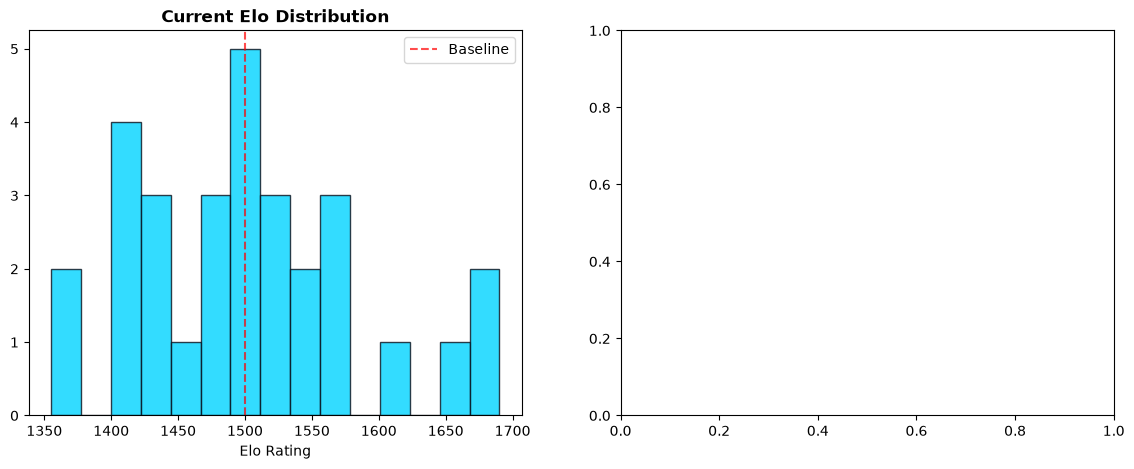

In [4]:
# Elo distribution
elo_values = list(current_elo.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(elo_values, bins=15, color='#00d4ff', edgecolor='#0a0e1a', alpha=0.8)
axes[0].axvline(1500, color='red', linestyle='--', alpha=0.7, label='Baseline')
axes[0].set_title('Current Elo Distribution', fontweight='bold')
axes[0].set_xlabel('Elo Rating')
axes[0].legend()

# East vs West
east_elos = [current_elo[t] for t in EASTERN_CONFERENCE if t in current_elo]
west_elos = [current_elo[t] for t in WESTERN_CONFERENCE if t in current_elo]
axes[1].boxplot([east_elos, west_elos], labels=['Eastern', 'Western'],
                patch_artist=True,
                boxprops=dict(facecolor='#00d4ff30'),
                medianprops=dict(color='#ff4757'))
axes[1].set_title('Elo by Conference', fontweight='bold')
axes[1].set_ylabel('Elo Rating')

plt.tight_layout()
plt.show()

print(f'East mean: {np.mean(east_elos):.0f} | West mean: {np.mean(west_elos):.0f}')

In [ ]:
# Elo predictive power
# How often does the higher-Elo team win?
df_elo = df[df['home_elo_before'].notna()].copy()
df_elo['higher_elo_home'] = df_elo['home_elo_before'] > df_elo['away_elo_before']
df_elo['home_win'] = df_elo['FTR'] == 'H'
df_elo['away_win'] = df_elo['FTR'] == 'A'

# When home has higher Elo
home_higher = df_elo[df_elo['higher_elo_home']]
away_higher = df_elo[~df_elo['higher_elo_home']]

print('When HOME has higher Elo:')
print(f'  Home Win: {home_higher["home_win"].mean():.1%}')
print(f'  Draw:     {(home_higher["FTR"]=="D").mean():.1%}')
print(f'  Away Win: {home_higher["away_win"].mean():.1%}')
print(f'\nWhen AWAY has higher Elo:')
print(f'  Home Win: {away_higher["home_win"].mean():.1%}')
print(f'  Draw:     {(away_higher["FTR"]=="D").mean():.1%}')
print(f'  Away Win: {away_higher["away_win"].mean():.1%}')

In [ ]:
# Elo diff vs. actual result
df_elo['elo_diff'] = df_elo['home_elo_before'] - df_elo['away_elo_before']
bins = pd.cut(df_elo['elo_diff'], bins=10)
win_rate = df_elo.groupby(bins)['home_win'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
win_rate.plot(kind='bar', ax=ax, color='#00c48c', alpha=0.8)
ax.set_title('Home Win Rate by Elo Difference', fontweight='bold')
ax.set_xlabel('Elo Difference (Home - Away)')
ax.set_ylabel('Home Win Rate')
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()